Models:
- Logistic Regression
- Random Forests
- XGBoost / LightGBM

Feature Importance: Global and Local (SHAP)

#### Sentiment analysis

$\text{Compound Score} = \frac{x}{\sqrt{x^2 + \alpha}}$, $\alpha = 15$

$x$ is the sum of the scores for all the words in the blurb. A word's score is high when it is assoociated with a positive sentiment and low (negative) when associated with a negative sentiment. This score is adjusted depending on the context in which the word is located.

#### Vocabulary Level

$\text{Readability Score} = 206.835 - 1.015 \left( \frac{\text{total words}}{\text{total sentences}} \right) - 84.6 \left( \frac{\text{total syllables}}{\text{total words}} \right)$

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
df_train, df_val = pd.read_csv("../data/features/train.csv"), pd.read_csv("../data/features/val.csv")

In [5]:
with open("../data/features/features_scale.txt", "r") as f:
    features_scale = [line.strip() for line in f.readlines()]

with open("../data/features/features_no_scale.txt", "r") as f:
    features_no_scale = [line.strip() for line in f.readlines()]

## Data Preparation

In [6]:
X_train = df_train[features_scale + features_no_scale]
y_train = df_train["target"]

X_val = df_val[features_scale + features_no_scale]
y_val = df_val["target"]

In [7]:
scaler = StandardScaler()

# Fit & Transform on train
X_train_scaled_num = scaler.fit_transform(X_train[features_scale])
X_train_scaled_num = pd.DataFrame(X_train_scaled_num, columns=features_scale, index=X_train.index)

# Transform (only) on val
X_val_scaled_num = scaler.transform(X_val[features_scale])
X_val_scaled_num = pd.DataFrame(X_val_scaled_num, columns=features_scale, index=X_val.index)

# Gathering all features together
X_train_final = pd.concat([X_train_scaled_num, X_train[features_no_scale]], axis=1)
X_val_final = pd.concat([X_val_scaled_num, X_val[features_no_scale]], axis=1)

### Correlation study

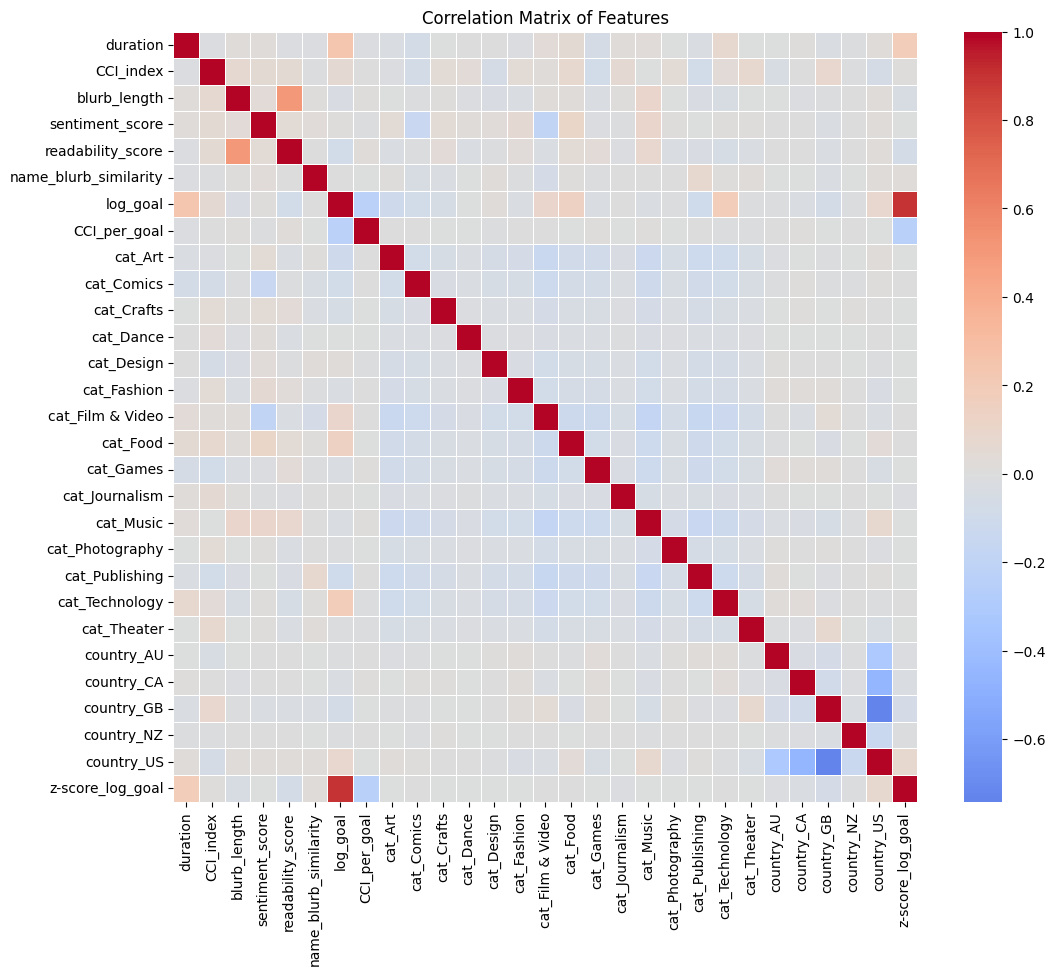

In [8]:
plt.figure(figsize=(12, 10))
corr_matrix = X_train_final.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

## Prediction with NLP features (only)

### Hyperparameter tuning

In [9]:
# RF GridSearch
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2
)
rf_grid.fit(X_train_final, y_train)
best_rf = rf_grid.best_estimator_
print(f"Best RF parameters: {rf_grid.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=   0.2s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=   0.2s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=100; total time=   0.2s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=200; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=200; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=2, n_estimators=200; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=100; total time=   0.2s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=200; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=5, n_estimators=200; total time=   0.4s
[CV] END .max_depth=10, min_samples_leaf=5, n_es

In [10]:
# XGBoost GridSearch
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_final, y_train, 
    train_size=0.25, 
    stratify=y_train, 
    random_state=42
)

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)
xgb_grid.fit(X_train_sample, y_train_sample)
best_xgb = xgb_grid.best_estimator_
print(f"Best XGBoost parameters: {xgb_grid.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits


[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.5s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.5s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.6s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=200; total time=   0.3s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   2.1s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.0

### Model Training & Evaluation


--- Evaluating Logistic Regression (Lasso) ---
Training Accuracy : 0.719
Training F1-Score : 0.782
Training ROC-AUC  : 0.771

Validation Accuracy : 0.716
Validation F1-Score : 0.777
Validation ROC-AUC  : 0.773





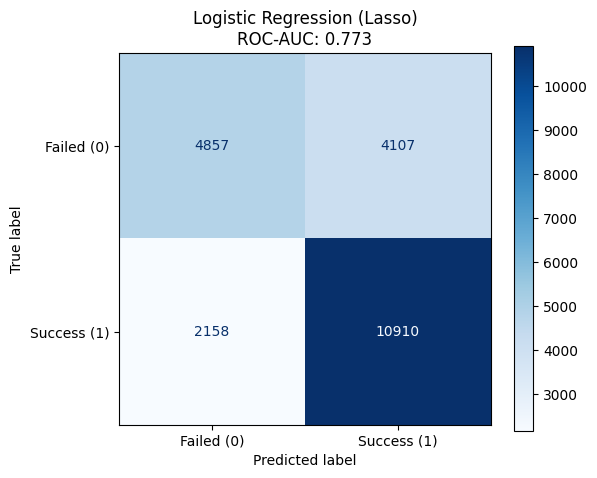


--- Evaluating Random Forest ---
Training Accuracy : 0.867
Training F1-Score : 0.898
Training ROC-AUC  : 0.954

Validation Accuracy : 0.731
Validation F1-Score : 0.791
Validation ROC-AUC  : 0.804





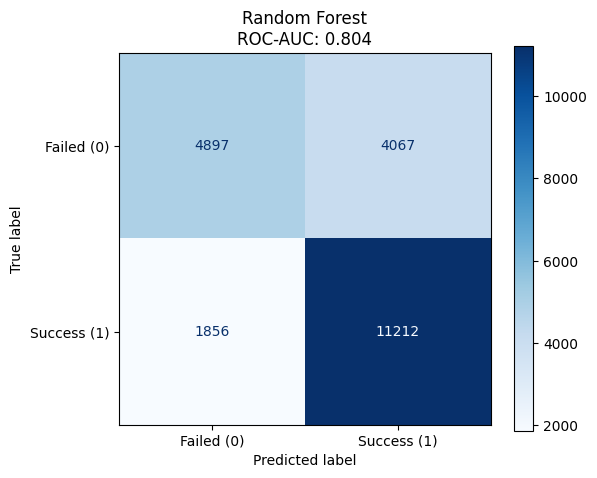


--- Evaluating XGBoost ---
Training Accuracy : 0.765
Training F1-Score : 0.818
Training ROC-AUC  : 0.840

Validation Accuracy : 0.736
Validation F1-Score : 0.792
Validation ROC-AUC  : 0.809





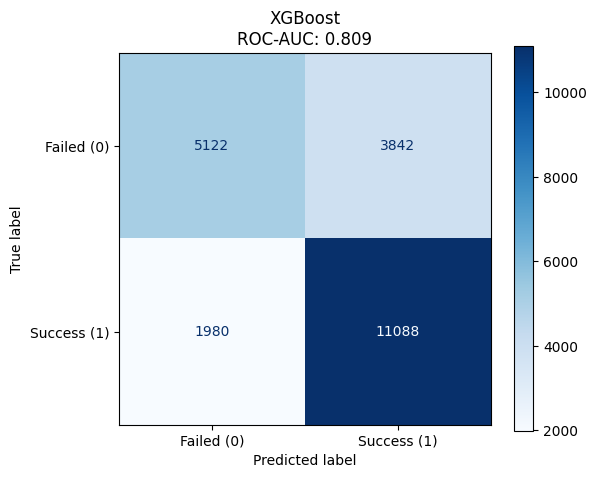

In [11]:
# models = {
#     "Logistic Regression (Lasso)": LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
#     "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# }

models = {
    "Logistic Regression (Lasso)": LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

for idx, (name, model) in enumerate(models.items()):
    print(f"\n--- Evaluating {name} ---")
    
    model.fit(X_train_final, y_train)

    # Predictions on training set
    y_pred_train = model.predict(X_train_final)
    y_pred_proba_train = model.predict_proba(X_train_final)[:, 1]
    
    # Predictions on validation set
    y_pred_val = model.predict(X_val_final)
    y_pred_proba_val = model.predict_proba(X_val_final)[:, 1]
    
    # Metrics on training set
    acc_train = accuracy_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)
    auc_train = roc_auc_score(y_train, y_pred_proba_train)

    # Metrics on validation set
    acc_val = accuracy_score(y_val, y_pred_val)
    f1_val = f1_score(y_val, y_pred_val)
    auc_val = roc_auc_score(y_val, y_pred_proba_val)

    print(f"Training Accuracy : {acc_train:.3f}")
    print(f"Training F1-Score : {f1_train:.3f}")
    print(f"Training ROC-AUC  : {auc_train:.3f}\n")

    print(f"Validation Accuracy : {acc_val:.3f}")
    print(f"Validation F1-Score : {f1_val:.3f}")
    print(f"Validation ROC-AUC  : {auc_val:.3f}\n")

    print("\n")
    
    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5)) 
    
    cm = confusion_matrix(y_val, y_pred_val)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Failed (0)", "Success (1)"])
    
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f"{name}\nROC-AUC: {auc_val:.3f}")
    
    plt.show()

## Feature Importance

### Global Feature Importance

In [14]:
rf_model = models["Random Forest"]
importances = best_rf.feature_importances_
feature_names = X_train_final.columns

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)
print("Most Important Features (Global) :")
print(df_importance.head(10))

Most Important Features (Global) :
                  Feature  Importance
7            CCI_per_goal    0.134117
1               CCI_index    0.122977
6                log_goal    0.115005
28       z-score_log_goal    0.103052
0                duration    0.098375
5   name_blurb_similarity    0.075208
4       readability_score    0.066366
3         sentiment_score    0.061957
2            blurb_length    0.036529
15               cat_Food    0.036029


### Local Feature Importance


SHAP Explanation for the project 0 (from sample) :
True class : 0
Predicted probability of success : 0.36


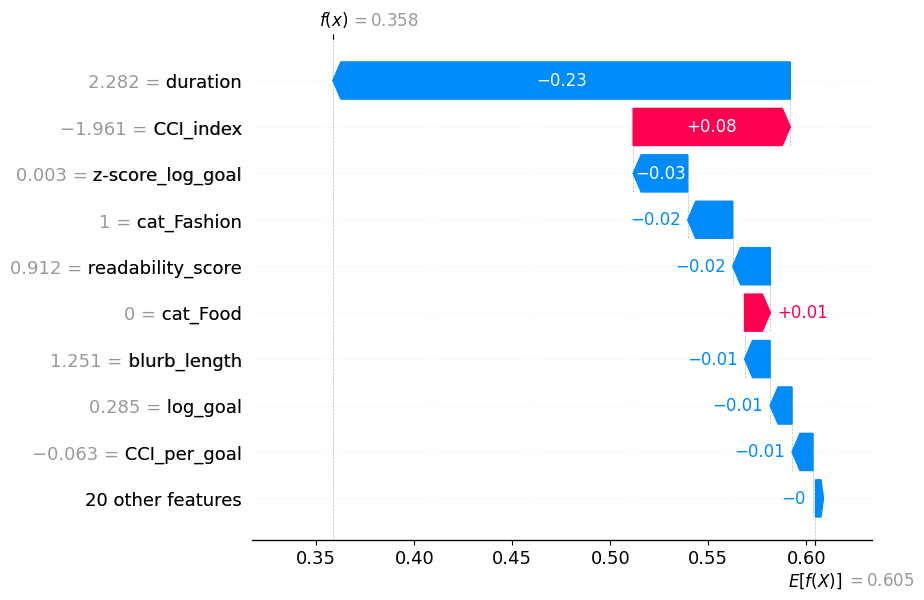

In [17]:
X_val_shap_sample = X_val_final.sample(n=100, random_state=42)

y_val_shap_sample = y_val.loc[X_val_shap_sample.index]

explainer = shap.TreeExplainer(best_rf)

shap_obj = explainer(X_val_shap_sample)


# Analyzing first project in the sample
index_projet = 0

print(f"\nSHAP Explanation for the project {index_projet} (from sample) :")
print(f"True class : {y_val_shap_sample.iloc[index_projet]}")
print(f"Predicted probability of success : {best_rf.predict_proba(X_val_shap_sample.iloc[[index_projet]])[0][1]:.2f}")

shap.initjs()
shap.plots.waterfall(shap_obj[index_projet, :, 1], max_display=10)